# Etude sur la vente des jeux vidéo en 2024-2025.

Ce document retrace les résultats de mes tests. Mais je ne sais plus comment aborder un dataset. Donc il faut apprendre

## 1. Observation des premières lignes du tableau et sélection des éléments importants.

In [3]:
# Import des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/vgchartz-2024.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [4]:
# Nettoyage des données 
df = df.dropna()
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,2018-11-02
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,2018-04-07
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,2018-04-07


On prendra les données suivantes :
- le type de ``"console"``, 
- le ``"genre"``, 
- le score : ``"critic_score"``, 
- le nombre total de ventes : ``"total_sales"`` 
- le studio choisi : ``"publisher"``

In [5]:
# Séparation & Nettoyage des données
data = df[["console", "genre", "critic_score", "total_sales", "publisher" ]]
data.head()

,console,genre,critic_score,total_sales,publisher
1,PS4,Action,9.7,19.39,Rockstar Games
4,PS4,Shooter,8.1,15.09,Activision
7,PS4,Action-Adventure,9.8,13.94,Rockstar Games
8,X360,Shooter,8.4,13.86,Activision
9,PS3,Shooter,8.0,13.80,Activision


In [6]:
data.describe()

,critic_score,total_sales
count,282.000000,282.000000
mean,7.659929,1.874149
std,1.203786,2.895821
min,3.000000,0.020000
25%,7.000000,0.370000
50%,7.900000,0.710000
75%,8.500000,1.882500
max,9.800000,19.390000


In [7]:
data["critic_score"].value_counts()

critic_score
8.1    19
8.0    19
7.9    18
7.5    15
8.5    15
8.6    10
7.0    10
8.3     9
9.0     9
7.6     9
8.8     8
8.7     8
8.4     7
6.9     7
9.3     7
7.4     7
8.9     6
7.7     6
6.0     6
9.1     5
6.7     5
6.6     5
9.5     4
7.2     4
5.5     4
8.2     4
6.3     4
5.9     4
7.3     4
7.1     3
9.4     3
6.2     3
6.5     3
5.0     3
4.8     3
9.7     2
6.8     2
5.8     2
9.2     2
5.4     2
6.1     2
7.8     2
5.7     2
9.8     1
3.2     1
5.1     1
5.6     1
5.2     1
3.0     1
5.3     1
4.3     1
4.7     1
4.5     1
Name: count, dtype: int64

In [8]:
data["total_sales"].head()

1    19.39
4    15.09
7    13.94
8    13.86
9    13.80
Name: total_sales, dtype: float64

## 2. Interprétation des données en visuel.

### 1. Relation linéaire entre le nombre de ventes et le score critique ? 

In [9]:
import matplotlib.pyplot as plt

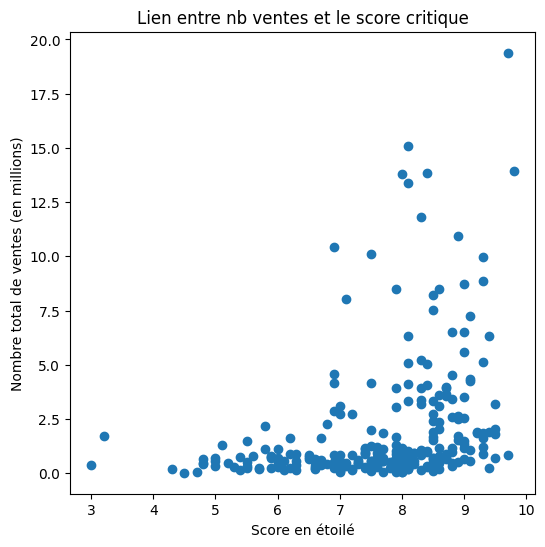

In [10]:
X = pd.Series(data["critic_score"])
y = pd.Series(data["total_sales"])
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.title("Lien entre nb ventes et le score critique")
plt.xlabel("Score en étoilé")
plt.ylabel("Nombre total de ventes (en millions)")
plt.show()

On introduit ensuite le modèle de régression linéaire. 

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
X = pd.array(X)
X = X.reshape(282,1)
print(X.shape)

(282, 1)


In [13]:
X.to_numpy(dtype='float', na_value=np.nan)                                 

model = LinearRegression()
model.fit(X, y)
print(f"{model.coef_=}, {model.intercept_=}")

model.coef_=array([0.75991653]), model.intercept_=np.float64(-3.946757804019368)


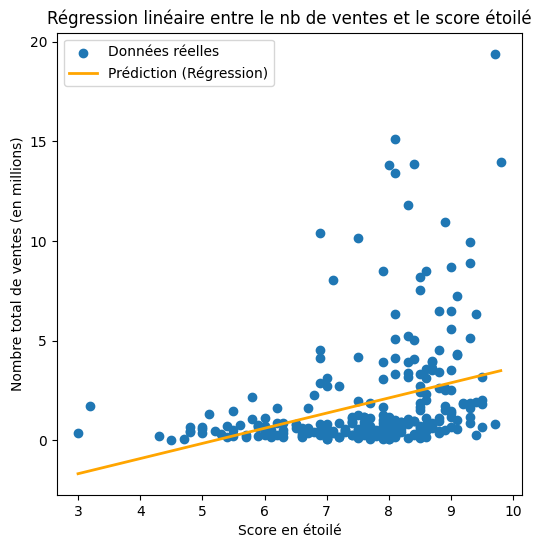

In [14]:
# Figure de base

X = pd.Series(data["critic_score"])
y = pd.Series(data["total_sales"])
plt.figure(figsize=(6, 6))
plt.scatter(X, y, label='Données réelles')

# Créer une séquence de X qui va du minimum au maximum des données
# reshape(-1, 1) est nécessaire pour scikit learn
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Prédiction
y_plot_pred = model.predict(X_plot)

plt.plot(X_plot, y_plot_pred, color='orange', linewidth=2, label='Prédiction (Régression)')
plt.title("Régression linéaire entre le nb de ventes et le score étoilé")
plt.xlabel("Score en étoilé")
plt.ylabel("Nombre total de ventes (en millions)")
plt.legend()
plt.show()

Comme on peut le constater, beaucoup de points sont bien en dehors de la fonction linéaire. Avec ces résultats, on en conclut que le modèle n'est pas adpaté pour ces caractéristiques. 

### 2. On tente d'autres modèles...

On tente la Régression Exponentielle vu sur YouTube. (https://www.youtube.com/watch?v=gHrM6E9FgKY)

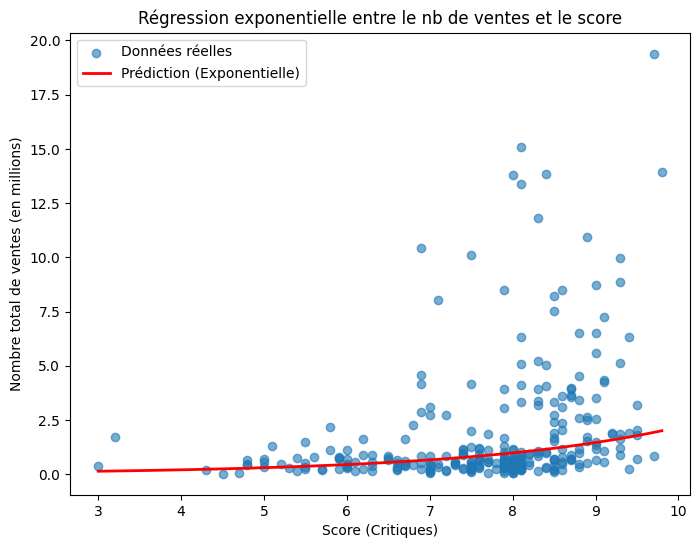

In [15]:
from scipy.stats import linregress

# 0. On s'assure d'utiliser les bonnes données en les extrayant à nouveau (en 1D natif)
X_clean = data["critic_score"].to_numpy()
y_clean = data["total_sales"].to_numpy()

# 1. Régression linéaire sur X et ln(y)
line = linregress(X_clean, np.log(y_clean))
slope = line.slope
y_int = line.intercept

# 2. Création d'un axe X "lisse" pour la courbe
X_smooth = np.linspace(X_clean.min(), X_clean.max(), 100)

# 3. Calcul de la prédiction exponentielle
# y = exp(intercept) * exp(slope * X)
y_expo_pred = np.exp(y_int) * np.exp(slope * X_smooth)

# 4. Tracé du graphique complet
plt.figure(figsize=(8, 6))
plt.scatter(X_clean, y_clean, label='Données réelles', alpha=0.6)
plt.plot(X_smooth, y_expo_pred, color='red', linewidth=2, label='Prédiction (Exponentielle)')

plt.title("Régression exponentielle entre le nb de ventes et le score")
plt.xlabel("Score (Critiques)")
plt.ylabel("Nombre total de ventes (en millions)")
plt.legend()
plt.show()

### 3. La régression polynomiale

On va tester une dernier modéle : la Régression polynomiale.

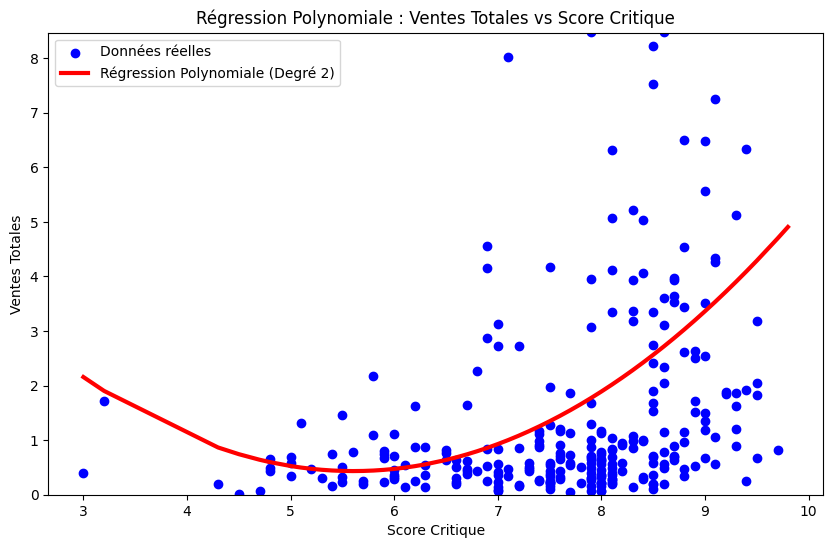

Score R² du modèle polynomial : 0.1323


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import operator

# 1. Préparation des données : retirer les valeurs manquantes pour éviter les erreurs
df_clean = data.dropna(subset=['critic_score', 'total_sales']).copy()

X = df_clean[['critic_score']].values
y = df_clean[['total_sales']].values

# 2. Trier les données selon X (très important pour que la ligne de la courbe s'affiche correctement et ne fasse pas des zigzags)
sorted_zip = sorted(zip(X, y), key=operator.itemgetter(0))
X_sorted, y_sorted = zip(*sorted_zip)
X_sorted = np.array(X_sorted)
y_sorted = np.array(y_sorted)

# 3. Création du modèle polynomial (Commençons par le degré 2)
# Degré 2 = parabole (une seule courbe). Degré 3 = forme en 'S' (deux courbes).
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X_sorted)

# 4. Entraînement du modèle de régression linéaire sur nos données transformées
poly_model = LinearRegression()
poly_model.fit(X_poly, y_sorted)

# 5. Prédictions (pour tracer la ligne)
y_poly_pred = poly_model.predict(X_poly)

# 6. Visualisation
plt.figure(figsize=(10, 6))

# Nuage de points des données réelles
plt.scatter(X_sorted, y_sorted, color='blue', label='Données réelles')

# Tracer la courbe du modèle
plt.plot(X_sorted, y_poly_pred, color='red', linewidth=3, label='Régression Polynomiale (Degré 2)')

plt.title("Régression Polynomiale : Ventes Totales vs Score Critique")
plt.xlabel("Score Critique")
plt.ylabel("Ventes Totales")
plt.legend()

# Limiter l'axe Y pour mieux voir la courbe (tu peux ajuster si tes ventes montent très haut)
plt.ylim(0, df_clean['total_sales'].quantile(0.95)) 

plt.show()

# Afficher le score R2 pour évaluer la précision mathématique du modèle
score_r2 = poly_model.score(X_poly, y_sorted)
print(f"Score R² du modèle polynomial : {score_r2:.4f}")

Je m'attendais à un courbe exponentielle. Mais non... je vais tenter de prendre en considération le score crtitique en rapport avec le ``publisher``. 

Pour savoir quels éditeurs sont les mieux notés, nous devons grouper les données par ``publisher``, puis calculer la moyenne de leurs scores critiques. Il est aussi crucial de compter le nombre de jeux par éditeur : un éditeur qui a un seul jeu noté 9.5 ne devrait pas forcément être classé au-dessus d'un éditeur qui a sorti 20 jeux avec une moyenne de 9.0.

In [20]:
# Grouper par éditeur, calculer la moyenne des scores et le nombre de jeux
publisher_scores = data.groupby('publisher')['critic_score'].agg(['mean', 'count']).reset_index()

# Renommer les colonnes pour plus de clarté
publisher_scores.columns = ['Éditeur', 'Score_Moyen', 'Nombre_de_jeux']

# Optionnel mais recommandé : filtrer pour ne garder que les éditeurs avec au moins 3 jeux 
# (pour éviter qu'un éditeur avec 1 seul très bon jeu ne fausse le classement)
publishers_filtres = publisher_scores[publisher_scores['Nombre_de_jeux'] >= 3]

# Trier par score moyen décroissant pour avoir les meilleurs en premier
top_publishers = publishers_filtres.sort_values(by='Score_Moyen', ascending=False)

# Afficher le top 10
top_publishers.head(10)

,Éditeur,Score_Moyen,Nombre_de_jeux
29,Rockstar Games,9.500000,3
22,Microsoft Studios,8.680000,5
0,2K Games,8.600000,3
1,2K Sports,8.257143,7
36,THQ,8.200000,6
6,Bethesda Softworks,8.190909,11
39,Ubisoft,8.133333,21
35,Square Enix,8.130769,13
34,Sony Interactive Entertainment,8.100000,5
17,Konami Digital Entertainment,7.887500,8


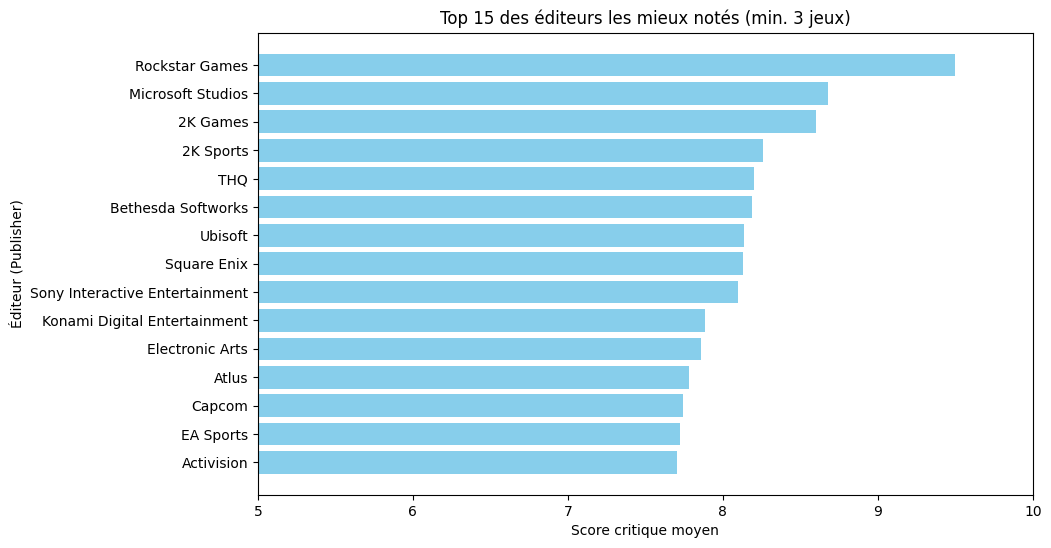

In [17]:
plt.figure(figsize=(10, 6))

# Création du graphique en barres
plt.barh(top_publishers['Éditeur'][:15], top_publishers['Score_Moyen'][:15], color='skyblue')

# Inverser l'axe Y pour que le meilleur soit tout en haut
plt.gca().invert_yaxis() 

plt.title("Top 15 des éditeurs les mieux notés (min. 3 jeux)")
plt.xlabel("Score critique moyen")
plt.ylabel("Éditeur (Publisher)")

# Définir la limite de l'axe X pour mieux voir les différences (les scores sont souvent entre 5 et 10)
plt.xlim(5, 10) 

plt.show()

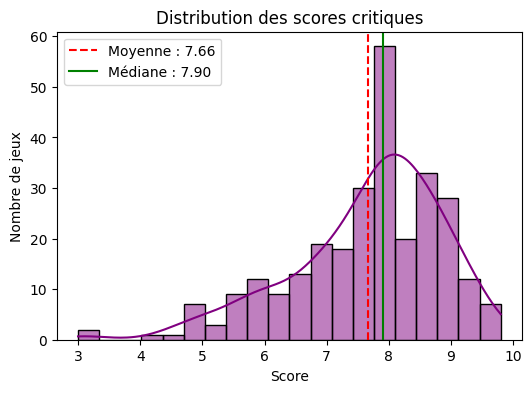

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

# Création de l'histogramme avec la courbe de densité (kde=True)
sns.histplot(data['critic_score'], bins=20, kde=True, color='purple')

# Ajout de lignes verticales pour la moyenne et la médiane
plt.axvline(data['critic_score'].mean(), color='red', linestyle='--', label=f"Moyenne : {data['critic_score'].mean():.2f}")
plt.axvline(data['critic_score'].median(), color='green', linestyle='-', label=f"Médiane : {data['critic_score'].median():.2f}")

plt.title("Distribution des scores critiques")
plt.xlabel("Score")
plt.ylabel("Nombre de jeux")
plt.legend()

plt.show()

## Sources

Youtube : 
- [Learn Pandas in 30 Minutes - Python Pandas Tutorial](https://www.youtube.com/watch?v=EXIgjIBu4EU)
- [scikit-learn: Exponential Regression](https://www.youtube.com/watch?v=gHrM6E9FgKY)
- [scikit-learn: Polynomial Regression](https://www.youtube.com/watch?v=H8kocPOT5v0)

Documentation : 
- http://scikit-learn.org/stable/
- [scikit-learn : Polynomial Features](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
- https://pandas.pydata.org

&copy; [Zoléni KOKOLO ZASSI](https://zolenikokolo.com) - 2026